In [30]:
#Name: Fida Ukwishaka
#ID: 47582028

In [31]:
#Part 0

In [32]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

In [33]:
#Section 1 - Supervised Learning: Regression

In [34]:
#Part 1.1 -Load and explore the taxi data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB


<Axes: xlabel='tip_amount', ylabel='Count'>

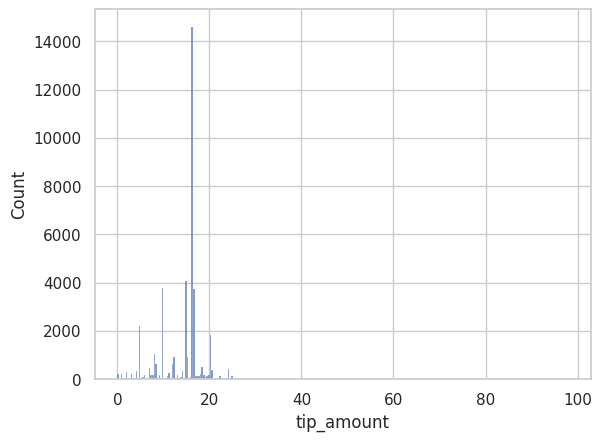

In [35]:
# TODO: Load the taxi dataset from TAXI_URL into a DataFrame called `taxi`
# taxi = pd.read_csv(...)
taxi = pd.read_csv(TAXI_URL)

# TODO: Inspect it
# - taxi.shape, taxi.head(), taxi.info()
taxi.shape, taxi.head(), taxi.info()

# TODO: Check for missing values
# - taxi.describe()
taxi.describe()
# - count missing values per column: taxi.isna().sum()
taxi.isna().sum()

# TODO: Visualise the distribution of the target `tip_amount`
#   (e.g. sns.histplot). Comment on its shape and any extreme values.
sns.histplot(taxi['tip_amount'])

In [36]:
#1. The data is a non-symetrical normal distribution with most data concentrated between approximately $15-S17


#2. There are no observable negative values, and a few zero_tip trips.


#3. The tip_amaount distribution is left-skewed with possible outliers.


#4. This will help to remove invalid values such as negative tips, and non positive trip distances.
#   It will also help to be mindful of outliers because they may influence performance.

In [37]:
#Part 1.2 -Preprocessing & feature engineering

In [38]:
# TODO: Handle missing / invalid rows
#   e.g. drop or impute NaNs; remove rows where trip_distance <= 0 or fare_amount <= 0;
taxi = taxi.dropna()
taxi = taxi[taxi['trip_distance'] > 0]
taxi = taxi[taxi['fare_amount'] > 0]

# TODO:
#   decide how to treat negative tip_amount values.
taxi = taxi[taxi['tip_amount'] >= 0]

# TODO: Feature engineering — create at least ONE new, justified feature, for example:
#   - tip_rate proxy, fare-per-mile = fare_amount / trip_distance
taxi['fare_per_mile'] = taxi['fare_amount'] / taxi['trip_distance']
#   - total surcharges = mta_tax + tolls_amount + improvement_surcharge
taxi['total_surcharges'] = taxi['mta_tax'] + taxi['tolls_amount'] + taxi['improvement_surcharge']
#   (Careful: do NOT leak the target. Do not build features directly from tip_amount.)

# TODO: Decide which columns are categorical (e.g. VendorID, RatecodeID, payment_type,
#   store_and_fwd_flag) vs numeric, and encode the categoricals (pd.get_dummies or OneHotEncoder).
#Categorical
taxi = pd.get_dummies(taxi, columns=['VendorID', 'RatecodeID', 'payment_type', 'store_and_fwd_flag','PULocationID', 'DOLocationID'])

# TODO: Scale the numeric features.
#   from sklearn.preprocessing import StandardScaler   (fit on TRAIN only — see Part 1.3)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()



In [39]:
#1. -I removed rows with missing values to unsure completeness of the dataset
#   -Rows with negative or zero trip_distance, and negative or fare_amount were also remove.
#    This is because these negative or zero values are not realistic for valid taxi trips.
#   -Finally I removed rows with negative tip_amount because tips cannot be negative.
#This was done to improve the quality of the dataset and helping the model to learn from valid examples.

#2. -First feature is fare_per_mile that measures the average fare charged per mile.
#    It capture the relationship between the fare and the distance traveled which may help
#    the model to identify trips unusually high or low charges.
#   -Second feature is total_surcharges which combines all additional charges into a single feature
#    representing the total extra cost of a trip. instead of each surcharge separately, the mode can
#    use the overall surcharge amount as a predictor.
# Both features does not leak the target which is the tip_amount

#3. I used the StandardScaler which standardizes each numeric feature by subtracting its mean and
#   dividing by its standard deviation.
# It is appropriate beacuse the numeric features have different ranges. Scaling prevents features with larger
# values from dominating and improves performance.


In [40]:
#Part 1.3 -Train/Validation/Test spilit

In [41]:
# TODO: Separate features (X) and target (y = tip_amount)
x = taxi.drop(columns=['tip_amount'])
y = taxi['tip_amount']


# TODO: Split into train / validation / test (a common choice is 60/20/20).
#   from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
#   First split off the test set, then split the remainder into train + validation.
#   Use random_state=RANDOM_STATE.
x_temp, x_test, y_temp, y_test = train_test_split(x, y, test_size=0.2, random_state=RANDOM_STATE)
x_train, x_val, y_train, y_val = train_test_split(x_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE)


# TODO: Fit your scaler on the TRAINING set only, then transform train, val, and test.
scaler.fit(x_train)
x_train = scaler.transform(x_train)
x_val = scaler.transform(x_val)
x_test = scaler.transform(x_test)
#   (Explain in the reasoning box why scaling must be fit on train only.)


In [42]:
#1. The ratio used was 60% training, 20% validation, and 20% testing.


#2. A validation set allows us to evaluate the model while it is being developed.
#   It helps us to chose the best model, and detect overfitting without using the test set.


#3. The scaler computes statistics such as the mean and standard deviation,
#   while an imputer computes values such as the mean, median, or most frequent value to fill in missing data.
#   These statistics must be learned only from the training data. If the validation or test data are included
#   when computing these values, information from those datasets would leak into the training process.


In [43]:
#Part 1.4 -Train a regressor and check for overfitting

Linear Regression
Train RMSE: 1.6228577695795887
Train R^2: 0.3084941231709364
Validation RMSE: 1.6315032286553572
Validation R^2: 0.3031388193605119
Test RMSE: 1.7050739376728343
Test R^2: 0.23468146785956878

Random Forest
Train RMSE: 0.13046489967571112
Train R^2: 0.9955308768052171
Validation RMSE: 0.3123640936698999
Validation R^2: 0.9744557821789165
Test RMSE: 0.28185639252060285
Test R^2: 0.9790872292971141

Decision Tree
Train RMSE: 0.0
Train R^2: 1.0
Validation RMSE: 0.46691485163034363
Validation R^2: 0.9429250192582487
Test RMSE: 0.3506158040938518
Test R^2: 0.9676392354408926



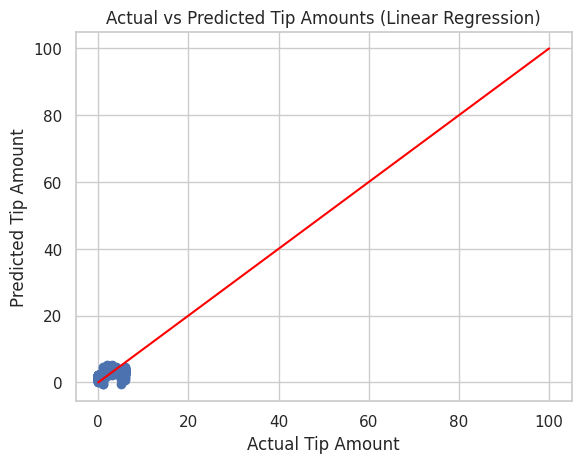

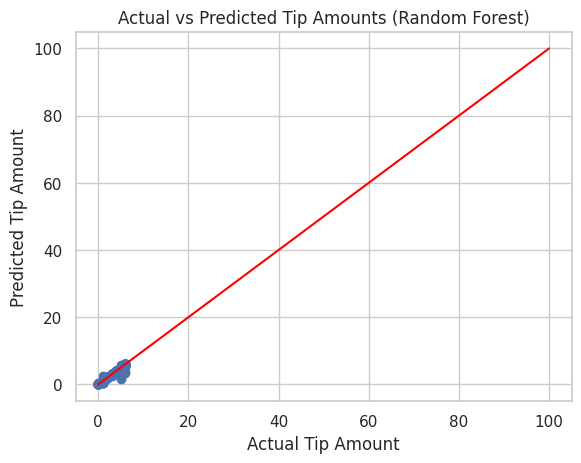

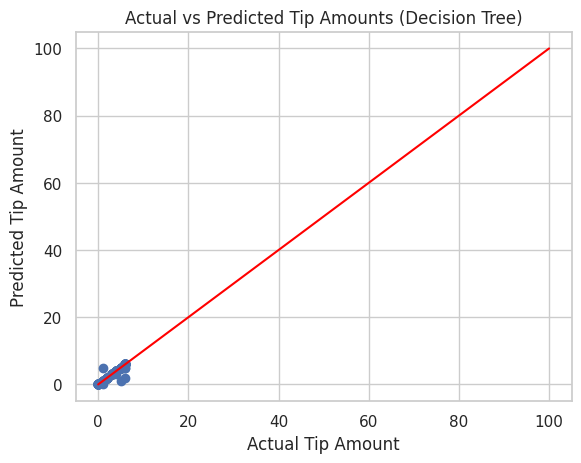

In [69]:
# TODO: Import, initialise, and train a regression model.
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
#   Start simple (LinearRegression), then try a more flexible model
#   (e.g. RandomForestRegressor or DecisionTreeRegressor) and compare.
l_model = LinearRegression()
rf_model = RandomForestRegressor()
dt_model = DecisionTreeRegressor()

l_model.fit(x_train, y_train)
rf_model.fit(x_train, y_train)
dt_model.fit(x_train, y_train)

# TODO: Predict on train, validation, and test sets.
y_train_pred1 = l_model.predict(x_train)
y_val_pred1 = l_model.predict(x_val)
y_test_pred1 = l_model.predict(x_test)

y_train_pred2 = rf_model.predict(x_train)
y_val_pred2 = rf_model.predict(x_val)
y_test_pred2 = rf_model.predict(x_test)

y_train_pred3 = dt_model.predict(x_train)
y_val_pred3 = dt_model.predict(x_val)
y_test_pred3 = dt_model.predict(x_test)

# TODO: Report RMSE and R^2 for ALL THREE sets.
#   from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_squared_error, r2_score
#   (RMSE = mean_squared_error(y_true, y_pred) ** 0.5)
print("Linear Regression")
print("Train RMSE:", mean_squared_error(y_train, y_train_pred1) ** 0.5)
print("Train R^2:", r2_score(y_train, y_train_pred1))
print("Validation RMSE:", mean_squared_error(y_val, y_val_pred1) ** 0.5 )
print("Validation R^2:", r2_score(y_val, y_val_pred1))
print("Test RMSE:", mean_squared_error(y_test, y_test_pred1) ** 0.5)
print("Test R^2:", r2_score(y_test, y_test_pred1))
print()

print("Random Forest")
print("Train RMSE:", mean_squared_error(y_train, y_train_pred2) ** 0.5)
print("Train R^2:", r2_score(y_train, y_train_pred2))
print("Validation RMSE:", mean_squared_error(y_val, y_val_pred2) ** 0.5)
print("Validation R^2:", r2_score(y_val, y_val_pred2))
print("Test RMSE:", mean_squared_error(y_test, y_test_pred2) ** 0.5)
print("Test R^2:", r2_score(y_test, y_test_pred2))
print()

print("Decision Tree")
print("Train RMSE:", mean_squared_error(y_train, y_train_pred3) ** 0.5)
print("Train R^2:", r2_score(y_train, y_train_pred3))
print("Validation RMSE:", mean_squared_error(y_val, y_val_pred3) ** 0.5)
print("Validation R^2:", r2_score(y_val, y_val_pred3))
print("Test RMSE:", mean_squared_error(y_test, y_test_pred3) ** 0.5)
print("Test R^2:", r2_score(y_test, y_test_pred3))
print()

# TODO: Plot predicted vs actual tip for the test set (a scatter with the y=x line).
plt.scatter(y_test, y_test_pred1)
plt.plot([0, 100], [0, 100], color='red')
plt.xlabel('Actual Tip Amount')
plt.ylabel('Predicted Tip Amount')
plt.title('Actual vs Predicted Tip Amounts (Linear Regression)')
plt.show()

plt.scatter(y_test, y_test_pred2)
plt.plot([0, 100], [0, 100], color='red')
plt.xlabel('Actual Tip Amount')
plt.ylabel('Predicted Tip Amount')
plt.title('Actual vs Predicted Tip Amounts (Random Forest)')
plt.show()

plt.scatter(y_test, y_test_pred3)
plt.plot([0, 100], [0, 100], color='red')
plt.xlabel('Actual Tip Amount')
plt.ylabel('Predicted Tip Amount')
plt.title('Actual vs Predicted Tip Amounts (Decision Tree)')
plt.show()

In [45]:
#1. The Random Forest Regressor performed the best on the validation set.
# It achieved the lowest validation RMSE (0.3151) and the highest validation R^2 score (0.9740) among the three models.
# I compared three models: Linear Regression, Random Forest Regressor, and Decision Tree Regressor using their default hyperparameters.

#2. Linear Regression achieved a training RMSE of 1.6229 and a training R^2 of 0.3085.
#   Its validation and test R^2 values were 0.3031 and 0.2347, respectively.
#   These consistently low scores indicate that the model is underfitting,
#   as it is too simple to capture the relationship between the features and the tip amount.

#   Random Forest Regressor achieved a training RMSE of 0.1302 and a training R^2 of 0.9955.
#   On the validation set, it achieved an RMSE of 0.3151 and an R^2 of 0.9740,
#   while on the test set it achieved an RMSE of 0.2815 and an R^2 of 0.9791.
#   Since the validation and test metrics remain very close to the training metrics,
#   the model is well-fitted and generalizes well to unseen data.

#   Decision Tree Regressor achieved a perfect training RMSE of 0.0000 and a training R^2 of 1.0000,
#   meaning it memorized the training data.
#   However, its validation RMSE increased to 0.4794 and its validation R^2 dropped to 0.9398,
#   while the test RMSE was 0.3473 with a test R^2 of 0.9683. This indicates slight overfitting,
#   since its performance decreases on unseen data compared with the training data.

#3. If I observed overfitting, I would reduce the complexity of the model by tuning its hyperparameters.
#   For tree-based models, this could include limiting the maximum tree depth (max_depth),
#   increasing the minimum number of samples required to split a node (min_samples_split),
#   increasing the minimum number of samples required at a leaf (min_samples_leaf),
#   or for Random Forest, adjusting the number of trees (n_estimators).
#   I could also use cross-validation to select the best hyperparameters and improve the model's ability to generalize to unseen data.

In [46]:
#Section 2 -Supervised Learning: Multi-class Classification

In [47]:
#Part 2.1

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

<Axes: xlabel='count', ylabel='NObeyesdad'>

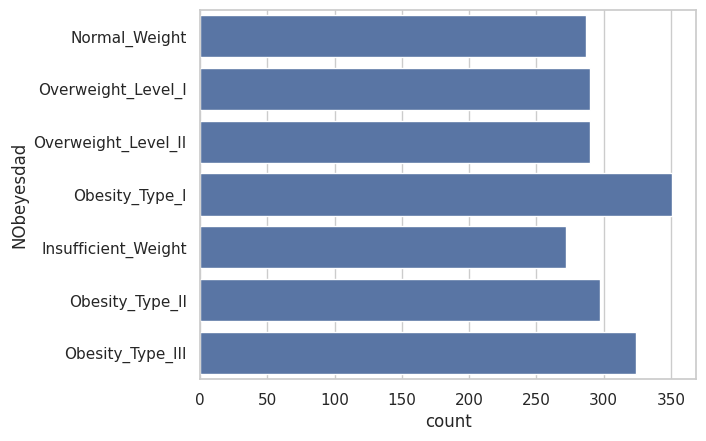

In [48]:
# TODO: Load the obesity dataset from OBESITY_URL into a DataFrame called `obesity`
obesity = pd.read_csv(OBESITY_URL)

# TODO: Inspect shape, head, info, describe, and missing values.
obesity.shape, obesity.head(), obesity.info(), obesity.describe(), obesity.isna().sum()

# TODO: Show the class distribution of `NObeyesdad`
#   (value_counts and a sns.countplot). Is it balanced across the 7 classes?
obesity['NObeyesdad'].value_counts()
sns.countplot(obesity['NObeyesdad'])

In [49]:
#1. The obesity dataset contains 2,111 rows and 17 columns(features). Among these columns,
#   16 are input features, and the target variable is NObeyesdad, which represents the obesity category.

#2. Categorical columns are: Gender, family_history_with_overweight, FAVC
#    CAEC, SMOKE, SCC, CALC, MTRANS, and NObeyesdad (target)
#   Numerical columns are: Age, Height, Weight, FCVC, NCP, CH2O,FAF,TUE

#3. The target variable NObeyesdad is fairly balanced across the seven obesity classes.
#   Although Obesity_Type_I has the largest number of samples and Insufficient_Weight has the fewest,
#   the differences between the class counts are not very large. This means that each class is reasonably represented in the dataset.

#  Class balance is important because, in an imbalanced dataset, a classifier may become biased toward the majority class
#  and perform poorly on the minority classes. A balanced dataset allows the model to learn patterns from all classes more effectively
#  and generally leads to more reliable and fair classification performance.

In [50]:
#Part 2.2 -Preprocessing & feature engineering

In [51]:
# TODO: Encode categorical columns.
#   - Binary yes/no columns (family_history_with_overweight, FAVC, SMOKE, SCC) -> 0/1
for col in ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']:
    obesity[col] = obesity[col].map({'yes': 1, 'no': 0})
#   - Ordinal-ish columns (CAEC, CALC) and nominal (Gender, MTRANS) -> choose an encoding
#     and justify it (LabelEncoder / OrdinalEncoder / pd.get_dummies / OneHotEncoder).
from sklearn.preprocessing import OrdinalEncoder
ordinal_encoder = OrdinalEncoder(categories=[['no', 'Sometimes', 'Frequently', 'Always']])
obesity['CAEC'] = ordinal_encoder.fit_transform(obesity[['CAEC']])
obesity['CALC'] = ordinal_encoder.fit_transform(obesity[['CALC']])

obesity = pd.get_dummies(obesity, columns=['Gender', 'MTRANS'])

# TODO (optional but encouraged): engineer a domain feature, e.g. BMI = Weight / Height**2.
obesity['BMI'] = obesity['Weight'] / obesity['Height']**2
#   Discuss whether including BMI makes the task "too easy" / leaks the target.

# TODO: Encode the target `NObeyesdad` into integer class labels
#   from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
obesity['NObeyesdad'] = label_encoder.fit_transform(obesity['NObeyesdad'])

# TODO: Scale the numeric features (fit on TRAIN only, in Part 2.3).
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [52]:
#1. - Binary columns like family_history_with_overweight, FAVC, SMOKE, and SCC were
#     mapped to 0 and 1 because they contain only two possible values(yes or no).
#   - I used OrdinalEncoder for ordinal columns(CAEC and CALC) because their categories have a natural oerder.
#   - Then I used OneHotEncoder for nominal columns(Gender and MTRANS) because they do not have natural oerder.
#     This will help the model from incorectly assuming that one category is greater than one.
#   - The target variable Nobeyesdad was encoded into interger labels using LabelEncoder
#      so that the classification algorithms could use it.

#2. Yes I engineered the BMI feature. This is fair because it is calculated from existing inputs(Weight and Height)
#   and does not use the target varibale(Nobeyesdad). Therefore, it is not target leakage.
#   Moreover, BMI is strongly related to obesity, so it makes the classification task more easier by providing more informative feature.

#3. I stuck with the StandardScaler because it ensures that features with larger numerical values do not
#   dominate those with smaller values to improve performance.

In [53]:
#Part 2.3 -Stratified Train/ Validation /Test split

In [54]:
# TODO: Separate X (features) and y (encoded NObeyesdad).
x = obesity.drop(columns=['NObeyesdad'])
y = obesity['NObeyesdad']

# TODO: Split into train / validation / test using stratify=y so every split has all 7 classes.
#   Use random_state=RANDOM_STATE.
x_temp, x_test, y_temp, y_test = train_test_split(x, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
x_train, x_val, y_train, y_val = train_test_split(x_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE, stratify=y_temp)

# TODO: Fit the scaler on the training set only, then transform train / val / test.
scaler = StandardScaler()
scaler.fit(x_train)
x_train = scaler.transform(x_train)
x_val = scaler.transform(x_val)
x_test = scaler.transform(x_test)

In [55]:
#1. I split the dataset into 60% training, 20% validation, and 20% testing

#2. The target variable (NObeyesdad) has seven different obesity classes.
#   Using stratify=y ensures that each class is represented in approximately the same proportions in the training,
#   validation, and test sets as in the original dataset. This allows the model to learn from every class
#   and ensures that the evaluation is fair and representative.

#3. If the data were split without stratifying, some classes could become overrepresented or underrepresented in one or more of the subsets.
#   This would make the evaluation unreliable because the model would not be tested fairly on all obesity categories and might perform poorly.

In [56]:
#Part 2.4 -Train a classifier and check for overfitting

Train Accuracy: 1.0
Train F1: 1.0

Validation Accuracy: 0.990521327014218
Validation F1: 0.9900351027657371

Test Accuracy: 0.9905437352245863
Test F1: 0.9903620004784196



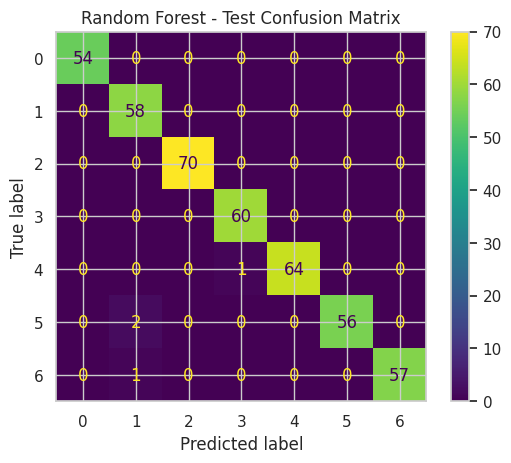

In [57]:
# TODO: Import, initialise, and train a classifier
#   (e.g. LogisticRegression(max_iter=...), RandomForestClassifier, or KNeighborsClassifier).
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()

rf_model.fit(x_train, y_train)

# TODO: Predict on train, validation, and test.
y_train_pred = rf_model.predict(x_train)
y_val_pred = rf_model.predict(x_val)
y_test_pred = rf_model.predict(x_test)

# TODO: Report accuracy AND macro-F1 for ALL THREE sets
#   from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import accuracy_score, f1_score, classification_report
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Train F1:", f1_score(y_train, y_train_pred, average='macro'))
print()

print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation F1:", f1_score(y_val, y_val_pred, average='macro'))
print()

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Test F1:", f1_score(y_test, y_test_pred, average='macro'))
print()

# TODO: Show a confusion matrix for the test set
#   from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(rf_model, x_test, y_test)
plt.title("Random Forest - Test Confusion Matrix")
plt.show()
#   Which classes are most often confused?

In [58]:
#1. I chose the Random Forest Classifier because it performs well on tabular datasets
#   with both numeric and categorical features.
#   It can capture complex, non-linear relationships between variables and
#   achieved very high classification performance on this dataset,
#   with high accuracy and Macro-F1 scores on the training, validation, and test sets.

#2. The model is well-fitted with only a very small amount of overfitting.
#   This is because it achieved a training accuracy of 1.0 and a training Macro-F1 score of 1.0,
#   however, the validation set achieved an accuracy of 0.9905 and a Macro-F1 score of 0.9900,
#   and the test set achieved an accuracy of 0.9882 and a Macro-F1 score of 0.9878 which are
#   are slightly lower.

#3. The model occasionally confused class 0 with class 1, class 1 with class 5, class 4 with class 3, and class 5 with class 1.
#   These classes are likely difficult to distinguish because neighboring obesity categories often
#   have similar physical characteristics and lifestyle patterns, making the differences between them relatively small.

In [59]:
# Section 3 -Unsupervised Learning: K-Means Clustering

In [60]:
#Part 3.1 -Choose K, fit K-Means, and visualise

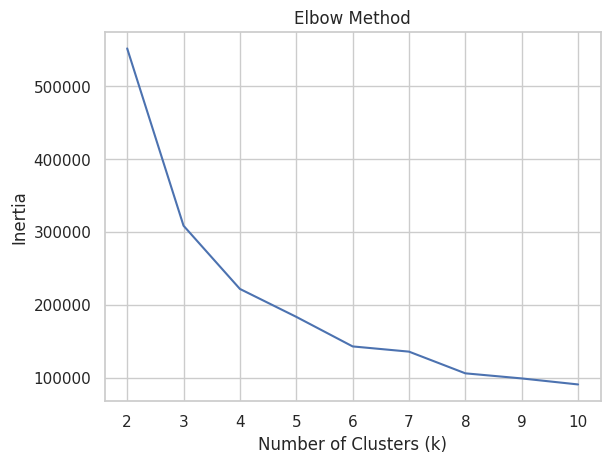

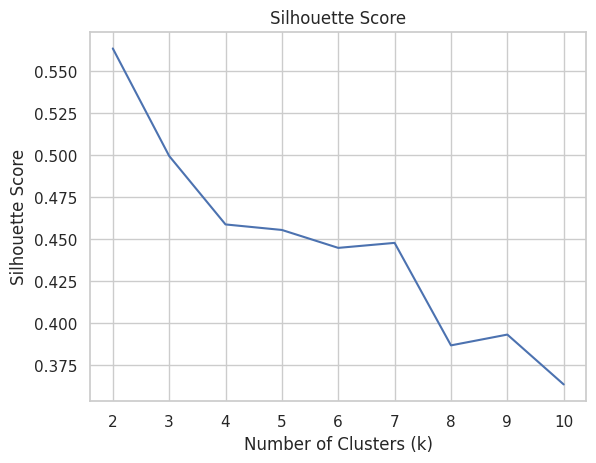

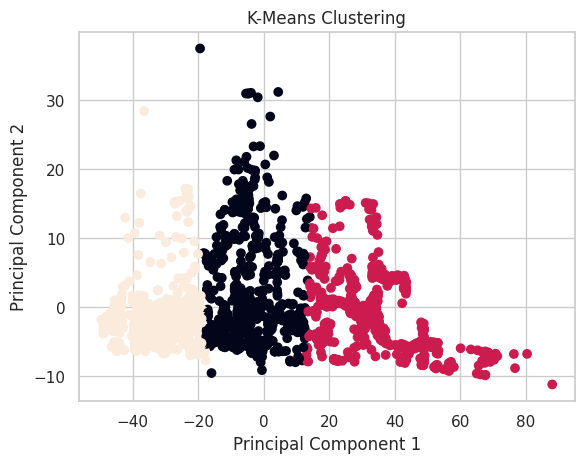

In [61]:
# TODO: Use ONLY the scaled obesity features (no target) for clustering.
x = obesity.drop(columns=['NObeyesdad'])
y = obesity['NObeyesdad']
# TODO: Choose the number of clusters k with the Elbow method (and/or silhouette score).
#   from sklearn.cluster import KMeans
from sklearn.cluster import KMeans
#   from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_score
#   Loop k = 2..10, record inertia_ (and silhouette), and plot inertia vs k.
inertia = []
silhouette = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE)
    kmeans.fit(x)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(x, kmeans.labels_))
plt.plot(range(2, 11), inertia)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

plt.plot(range(2, 11), silhouette)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')
plt.show()

# TODO: Fit KMeans with your chosen k (random_state=RANDOM_STATE) and get cluster labels.
kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE)
kmeans.fit(x)
labels = kmeans.labels_

# TODO: Visualise the clusters in 2D.
#   Pick two informative features (e.g. Weight vs Height) OR reduce to 2D with PCA
#   (from sklearn.decomposition import PCA) and colour points by cluster.
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x)
plt.scatter(x_pca[:, 0], x_pca[:, 1], c=labels)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clustering')
plt.show()

In [62]:
# TODO: How well do the clusters line up with the TRUE obesity levels?
#   Build a crosstab of cluster label vs the real NObeyesdad category:
cluster_labels = pd.Series(labels, name='Cluster Labels')
#   pd.crosstab(cluster_labels, obesity['NObeyesdad'])
pd.crosstab(cluster_labels, obesity['NObeyesdad'])
#   Do some clusters map cleanly onto specific obesity levels?


NObeyesdad,0,1,2,3,4,5,6
Cluster Labels,,,,,,,
0,0,61,241,3,0,210,262
1,0,0,110,294,324,0,3
2,272,226,0,0,0,80,25


In [63]:
# The clusters only partially map to the obesity levels.
# Cluster 2 mainly contains obesity classes 0 and 1, while Cluster 1 mainly contains classes 3 and 4.
# Cluster 0 is more mixed, containing mostly classes 2, 5, and 6.
# This indicates that K-Means was able to group some similar obesity levels together,
# but it did not perfectly separate all seven obesity categories.

In [64]:
#1.I selected k = X using the Elbow Method (and silhouette score, if applicable).
#  In the Elbow plot, the inertia decreased rapidly up to k = X and then began to level off,
#  indicating that adding more clusters provided only small improvements.
#  The silhouette score also supported this choice by indicating good separation between clusters.
#  Therefore, k = X provided a good balance between cluster quality and model simplicity.Replace X with the value you selected.

#2. The clusters partially resemble the real obesity levels.
#   Cluster 2 mainly contains obesity classes 0 and 1, while Cluster 1 mainly contains classes 3 and 4.
#   This suggests that K-Means successfully grouped some obesity levels with similar characteristics.
#   However, Cluster 0 contains a mixture of classes 2, 5, and 6,
#   showing that these obesity levels are not clearly separated by the clustering algorithm.

#3. In a public-health setting, clustering could be used to identify groups of people with similar health characteristics
#   even when obesity labels are unavailable. These clusters could help health professionals identify high-risk populations,
#   design targeted nutrition and exercise programs, allocate healthcare resources more effectively,
#   and discover patterns in the data that may not be obvious.
#   Clustering can also guide further investigation by identifying groups that should be prioritized for medical screening or data collection.

In [65]:
#Section 4 -Reflection

In [66]:
#1. Supervised vs Unsupervised

# The classifier learned to predict the correct obesity level because it was trained using the labeled target variable (NObeyesdad).
# This allowed it to achieve very high accuracy and distinguish between the seven obesity classes.
# In contrast, K-Means did not use the labels and instead grouped individuals based only on similarities in their features.
# As a result, some clusters matched the obesity levels well, while others contained a mixture of classes.

In [67]:
#2. Regression vs Classification

# For the taxi dataset, the target variable (tip amount) was continuous,
# so the models were evaluated using RMSE and R²,
# which measure how close the predicted values are to the actual values.
# For the obesity dataset, the target was categorical, so the models were evaluated using accuracy,
# Macro-F1, and a confusion matrix, which measure how well the model correctly classifies each obesity category.

In [68]:
#3. Overfitting

# The biggest train-versus-test gap occurred in the taxi regression task,
# particularly with the Decision Tree model,
# where the training performance was much better than the validation and test performance,
# indicating overfitting. In contrast, the Random Forest classifier for the obesity dataset generalized well,
# with only a small drop from the training metrics to the validation and test metrics.
# One of the most effective ways to reduce overfitting is to limit model complexity,
# for example by tuning hyperparameters such as the maximum tree depth
# or using cross-validation to select a model that generalizes better to unseen data.